# Eureka Experiment Viewer

Set `EUREKA_DIR` to a directory such as `/home/kang/CRAFT/logs/04-28_15-42/eureka`, then run all cells. The notebook loads and displays `scalar_summary.pkl`, `scalars.pkl`, `iteration_summary.pkl`, and `eureka_summary.pkl`.

In [1]:
from pathlib import Path
import pickle
import pprint

import matplotlib.pyplot as plt
import pandas as pd

# Change this path before running the notebook.
EUREKA_DIR = Path('/home/kang/CRAFT/logs/04-28_15-42/eureka')

assert EUREKA_DIR.exists(), f'Path does not exist: {EUREKA_DIR}'
assert EUREKA_DIR.is_dir(), f'Path is not a directory: {EUREKA_DIR}'
print(EUREKA_DIR)

/home/kang/CRAFT/logs/04-28_15-42/eureka


In [2]:
def load_pickle(path):
    with open(path, 'rb') as f:
        return pickle.load(f)

def short_value(value, max_len=500):
    text = pprint.pformat(value, width=120, compact=True)
    if len(text) > max_len:
        return text[:max_len] + ' ...'
    return text

def iter_dirs(eureka_dir):
    return sorted(
        [p for p in eureka_dir.glob('iteration_*') if p.is_dir()],
        key=lambda p: int(p.name.split('_')[-1]),
    )

def candidate_dirs(iter_dir):
    return sorted(
        [p for p in iter_dir.glob('candidate_*') if p.is_dir()],
        key=lambda p: int(p.name.split('_')[-1]),
    )

def flatten_scalar_summary(summary, iteration, candidate):
    rows = []
    for tag, stats in summary.items():
        row = {'iteration': iteration, 'candidate': candidate, 'tag': tag}
        row.update(stats)
        rows.append(row)
    return rows

print('Iterations:', [p.name for p in iter_dirs(EUREKA_DIR)])

Iterations: ['iteration_0', 'iteration_1']


## Eureka Summary

In [3]:
summary_path = EUREKA_DIR / 'eureka_summary.pkl'
if summary_path.exists():
    eureka_summary = load_pickle(summary_path)
    print('Keys:', list(eureka_summary.keys()))
    for key in ['task', 'num_iterations', 'num_candidates', 'training_iter', 'objective_terms', 'tie_breaker_terms']:
        if key in eureka_summary:
            print(f'\n{key}:')
            print(short_value(eureka_summary[key], max_len=1200))
    if 'best_candidate' in eureka_summary:
        best = eureka_summary['best_candidate']
        print('\nbest_candidate:')
        for key in ['iteration', 'candidate_idx', 'score', 'tie_score', 'candidate_dir', 'model_dir', 'event_dir']:
            if key in best:
                print(f'{key}: {best[key]}')
else:
    print(f'Missing {summary_path}')

Keys: ['task', 'num_iterations', 'num_candidates', 'training_iter', 'objective_terms', 'tie_breaker_terms', 'best_candidate', 'all_candidates']

task:
'go2pushbox'

num_iterations:
2

num_candidates:
2

training_iter:
1000

objective_terms:
[{'mode': 'max', 'stat': 'last', 'tag': 'Eval/agent_0_success_rate', 'weight': 1.0},
 {'mode': 'max', 'stat': 'last', 'tag': 'Eval/agent_1_success_rate', 'weight': 1.0},
 {'mode': 'min', 'stat': 'last', 'tag': 'Eval/box_distance_to_target', 'weight': 0.1}]

tie_breaker_terms:
[{'mode': 'max', 'stat': 'mean', 'tag': 'Eval/box_progress', 'weight': 1.0}]

best_candidate:
iteration: 0
candidate_idx: 0
score: -inf
tie_score: -inf
candidate_dir: logs/04-28_15-42/eureka/iteration_0/candidate_0
model_dir: logs/04-28_15-42/eureka/iteration_0/candidate_0/model
event_dir: training-log/MQE-Eureka/go2pushbox/eureka_04-28_15-42_go2pushbox_iter_0_candidate_0/tensorboard


## Iteration Summaries

In [4]:
iteration_rows = []
for iter_dir in iter_dirs(EUREKA_DIR):
    iteration = int(iter_dir.name.split('_')[-1])
    path = iter_dir / 'iteration_summary.pkl'
    if not path.exists():
        continue
    data = load_pickle(path)
    iteration_rows.append({
        'iteration': iteration,
        'best_candidate_idx': data.get('best_candidate_idx'),
        'best_score': data.get('best_score'),
        'best_tie_score': data.get('best_tie_score'),
        'num_candidates': len(data.get('candidates', [])),
        'has_reflection': bool(data.get('reflection')),
    })

iteration_df = pd.DataFrame(iteration_rows)
display(iteration_df)

for iter_dir in iter_dirs(EUREKA_DIR):
    path = iter_dir / 'iteration_summary.pkl'
    if path.exists():
        data = load_pickle(path)
        print(f"\n=== {iter_dir.name} reflection ===")
        print(data.get('reflection', ''))

,iteration,best_candidate_idx,best_score,best_tie_score,num_candidates,has_reflection
0,0,0,-inf,-inf,2,True
1,1,0,-inf,-inf,2,True



=== iteration_0 reflection ===
Use the following training feedback to improve the reward function.
Best candidate: iteration 0, candidate 0, score -inf.

Candidate summaries:
- iteration 0 candidate 0: trained, score -inf
- iteration 0 candidate 1: trained, score -inf

Revise the reward to improve the objective metrics, remove terms that create high reward without task progress, and keep useful shaping terms from the best candidate.

=== iteration_1 reflection ===
Use the following training feedback to improve the reward function.
Best candidate: iteration 1, candidate 0, score -inf.

Candidate summaries:
- iteration 1 candidate 0: trained, score -inf
- iteration 1 candidate 1: trained, score -inf

Revise the reward to improve the objective metrics, remove terms that create high reward without task progress, and keep useful shaping terms from the best candidate.


## Scalar Summary Tables

In [5]:
rows = []
for iter_dir in iter_dirs(EUREKA_DIR):
    iteration = int(iter_dir.name.split('_')[-1])
    for cand_dir in candidate_dirs(iter_dir):
        candidate = int(cand_dir.name.split('_')[-1])
        path = cand_dir / 'scalar_summary.pkl'
        if path.exists():
            rows.extend(flatten_scalar_summary(load_pickle(path), iteration, candidate))

scalar_summary_df = pd.DataFrame(rows)
if not scalar_summary_df.empty:
    display(scalar_summary_df.sort_values(['iteration', 'candidate', 'tag']).reset_index(drop=True))
else:
    print('No scalar_summary.pkl files found.')

No scalar_summary.pkl files found.


## Candidate Scores

,iteration,candidate,score,tie_score,error,candidate_dir
0,0,0,-inf,-inf,False,logs/04-28_15-42/eureka/iteration_0/candidate_0
1,0,1,-inf,-inf,False,logs/04-28_15-42/eureka/iteration_0/candidate_1
2,1,0,-inf,-inf,False,logs/04-28_15-42/eureka/iteration_1/candidate_0
3,1,1,-inf,-inf,False,logs/04-28_15-42/eureka/iteration_1/candidate_1


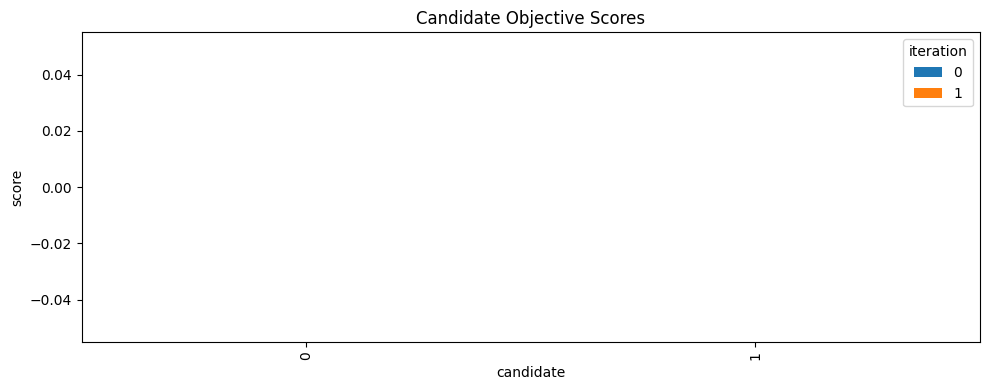

In [6]:
candidate_rows = []
for iter_dir in iter_dirs(EUREKA_DIR):
    summary_path = iter_dir / 'iteration_summary.pkl'
    if not summary_path.exists():
        continue
    data = load_pickle(summary_path)
    for candidate in data.get('candidates', []):
        candidate_rows.append({
            'iteration': candidate.get('iteration'),
            'candidate': candidate.get('candidate_idx'),
            'score': candidate.get('score'),
            'tie_score': candidate.get('tie_score'),
            'error': bool(candidate.get('error')),
            'candidate_dir': candidate.get('candidate_dir'),
        })

candidate_df = pd.DataFrame(candidate_rows)
display(candidate_df)

if not candidate_df.empty:
    ax = candidate_df.pivot(index='candidate', columns='iteration', values='score').plot(kind='bar', figsize=(10, 4))
    ax.set_title('Candidate Objective Scores')
    ax.set_ylabel('score')
    plt.tight_layout()
    plt.show()

## Plot Scalar Histories

In [7]:
def load_all_scalars(eureka_dir):
    records = []
    for iter_dir in iter_dirs(eureka_dir):
        iteration = int(iter_dir.name.split('_')[-1])
        for cand_dir in candidate_dirs(iter_dir):
            candidate = int(cand_dir.name.split('_')[-1])
            path = cand_dir / 'scalars.pkl'
            if not path.exists():
                continue
            scalars = load_pickle(path)
            for tag, points in scalars.items():
                for step, value in points:
                    records.append({
                        'iteration': iteration,
                        'candidate': candidate,
                        'tag': tag,
                        'step': step,
                        'value': value,
                    })
    return pd.DataFrame(records)

scalars_df = load_all_scalars(EUREKA_DIR)
print(f'Loaded {len(scalars_df)} scalar points')
display(scalars_df.head())

Loaded 0 scalar points


""


In [8]:
# Edit these filters to focus the plots.
TAG_FILTER = None  # e.g. 'Eval/' or 'Reward/' or None
MAX_TAGS = 12

if scalars_df.empty:
    print('No scalars.pkl data found.')
else:
    plot_df = scalars_df.copy()
    if TAG_FILTER:
        plot_df = plot_df[plot_df['tag'].str.contains(TAG_FILTER, regex=False)]
    tags = sorted(plot_df['tag'].unique())[:MAX_TAGS]
    for tag in tags:
        tag_df = plot_df[plot_df['tag'] == tag]
        plt.figure(figsize=(10, 4))
        for (iteration, candidate), group in tag_df.groupby(['iteration', 'candidate']):
            group = group.sort_values('step')
            plt.plot(group['step'], group['value'], label=f'iter {iteration} cand {candidate}')
        plt.title(tag)
        plt.xlabel('step')
        plt.ylabel('value')
        plt.legend(loc='best', fontsize=8)
        plt.tight_layout()
        plt.show()

No scalars.pkl data found.


## Raw Pickle Browser

In [9]:
pickle_paths = sorted(EUREKA_DIR.glob('eureka_summary.pkl'))
pickle_paths += sorted(EUREKA_DIR.glob('iteration_*/iteration_summary.pkl'))
pickle_paths += sorted(EUREKA_DIR.glob('iteration_*/candidate_*/scalar_summary.pkl'))
pickle_paths += sorted(EUREKA_DIR.glob('iteration_*/candidate_*/scalars.pkl'))

for path in pickle_paths:
    rel = path.relative_to(EUREKA_DIR)
    data = load_pickle(path)
    print(f'\n===== {rel} =====')
    if isinstance(data, dict):
        print('keys:', list(data.keys()))
    print(short_value(data, max_len=2000))


===== eureka_summary.pkl =====
keys: ['task', 'num_iterations', 'num_candidates', 'training_iter', 'objective_terms', 'tie_breaker_terms', 'best_candidate', 'all_candidates']
{'all_candidates': [{'answer': '```python\n'
                               'def gpt_reward(self, state, action):\n'
                               '    device = action.device\n'
                               '    reward = torch.zeros((self.num_envs, self.num_agents), device=device)\n'
                               '    rew_dict = {}\n'
                               '    max_reward = 10.0\n'
                               '\n'
                               '    # --- Core task progress: push the box toward the target ---\n'
                               '    toward_target = self._box_movement_toward_target(state, action)\n'
                               '    toward_target = self._check_reward_shape(toward_target)\n'
                               '    progress_reward = 2.2 * torch.tanh(0.8 * toward_target)\